# 03 · 테스트 · 이상탐지 · 평가

전처리된 **테스트 데이터**를 학습 모델로 진단. 파일만 바꿔 반복 실행.
설정은 **`config.py`**에서 로드(학습과 동일해야 함).

**PCA 모드 비교** (`config.py`의 `pca_mode`):
- `'consistent'` : 학습에서 저장한 pca/scaler를 **transform만** (정석) — 좌표계 일치
- `'original'`   : 테스트 데이터로 **각자 fit_transform** (원본 재현)

같은 테스트 파일에 대해 두 모드로 각각 돌려 F-score를 비교하면 차이를 볼 수 있다.

> 평가용 `anomalies`(find_anomalies)와 시각화용 `anomalies_plot`(gt/pred)을 이름 분리 → 셀 재실행 안전.

In [1]:
from function_def import *
from parameter import CFG
import os, math, numpy as np, pandas as pd, joblib
import tensorflow as tf
from pandas.plotting import register_matplotlib_converters
import matplotlib.pyplot as plt

## 하이퍼파라미터 로드 (학습과 동일한 config)

In [2]:
# 학습에서 win_size 등을 바꿔 make_config 했다면 여기서도 동일하게 맞출 것
# from config import make_config
# CFG = make_config(win_size=30)

win_size     = CFG['win_size']
features_dim = CFG['features_dim']
feat_dim     = CFG['feat_dim']
latent_dim   = CFG['latent_dim']
batch_size   = CFG['batch_size']
k_size       = CFG['k_size']
lstm_units   = CFG['lstm_units']
drop_gen     = CFG['dropout_rate_gen']
crit_filters = CFG['critic_filters']
crit_drop    = CFG['critic_dropout']
diffs_n, lags_n, smooth_n = CFG['diffs_n'], CFG['lags_n'], CFG['smooth_n']
pca_mode = CFG['pca_mode']

shape                   = CFG['shape']
encoder_input_shape     = CFG['encoder_input_shape']
encoder_reshape_shape   = CFG['encoder_reshape_shape']
generator_input_shape   = CFG['generator_input_shape']
generator_reshape_shape = CFG['generator_reshape_shape']
critic_x_input_shape    = CFG['critic_x_input_shape']
critic_z_input_shape    = CFG['critic_z_input_shape']
ckpt_dir = CFG['ckpt_dir']
print("win_size=%d k_size=%d pca_mode=%s" % (win_size, k_size, pca_mode))

win_size=10 k_size=2 pca_mode=original


## 설정 (테스트 파일 · 라벨)

In [3]:
TEST_CSV  = './data/preprocessed/test/Test07_NG_dchg.csv'
LABEL_CSV = './data/preprocessed/test/Test07_NG_dchg_Label.csv'
TITLE     = 'Test07_NG'
print("TEST:", TEST_CSV, "| mode:", pca_mode)

TEST: ./data/preprocessed/test/Test07_NG_dchg.csv | mode: original


## 1) 로드 → featurize → PCA/스케일 (모드 분기)

- **consistent**: 학습에서 저장한 pca/scaler 로드 후 `transform`만 (fit 안 함)
- **original**  : 테스트 데이터로 `fit_transform`

In [4]:
df_test1 = pd.read_csv(TEST_CSV)
data_1 = diff_smooth_df(df_test1, lags_n, diffs_n, smooth_n)

if pca_mode == 'consistent':
    pca = joblib.load(CFG['pca_path'])        # 학습 PCA 재사용
    data = pca.transform(data_1)              # fit 없이 변환만
    print("PCA: 학습 축 재사용(transform)")
else:
    pca = PCA(n_components=features_dim)  # 테스트 데이터로 새로 fit
    data = pca.fit_transform(data_1)          # 테스트 데이터로 새로 fit
    print("PCA: 테스트 데이터로 fit_transform")

df_1 = []
for i in range(len(data)):
    row = [i + 1] + [data[i][jj] for jj in range(features_dim)]
    df_1.append(row)
df = pd.DataFrame(df_1)
df.columns = ['date'] + ['pca_%s' % str(i) for i in range(1, features_dim + 1)]
print("After PCA:", df.shape)

PCA: 테스트 데이터로 fit_transform
After PCA: (4594, 4)


In [5]:
X, index = time_segments_aggregate(df, interval=1, time_column='date')
X = SimpleImputer().fit_transform(X)

if pca_mode == 'consistent':
    scaler = joblib.load(CFG['scaler_path'])  # 학습 스케일러 재사용
    X = scaler.transform(X)
else:
    X = MinMaxScaler(feature_range=(-1, 1)).fit_transform(X)

X, y, X_index, y_index = rolling_window_sequences(
    X, index, window_size=win_size, target_size=1, step_size=1, target_column=0)
print("after window:", X.shape)

after window: (4584, 10, 3)


## 2) 모델 재구성 → 체크포인트 로드

In [6]:
encoder   = build_encoder_layer(encoder_input_shape, encoder_reshape_shape,
                                win_size=win_size, latent_dim=latent_dim)
generator = build_generator_layer(generator_input_shape, generator_reshape_shape,
                                  win_size=win_size, features_dim=features_dim,
                                  lstm_units=lstm_units, dropout_rate=drop_gen)
critic_x  = build_critic_x_layer(critic_x_input_shape, k_size=k_size,
                                 filters=crit_filters, dropout_rate=crit_drop)
critic_z  = build_critic_z_layer(critic_z_input_shape)

z = Input(shape=(latent_dim, 1)); x = Input(shape=shape)
x_ = generator(z); z_ = encoder(x)
critic_x_model = Model([x, z],
    [critic_x(x), critic_x(x_), RandomWeightedAverage(batch_size)([x, x_])])
critic_z_model = Model([x, z],
    [critic_z(z), critic_z(z_), RandomWeightedAverage(batch_size)([z, z_])])
z_gen = Input(shape=(latent_dim, 1)); x_gen = Input(shape=shape)
x_gen_ = generator(z_gen); z_gen_ = encoder(x_gen); x_gen_rec = generator(z_gen_)
encoder_generator_model = Model([x_gen, z_gen],
    [critic_x(x_gen_), critic_z(z_gen_), x_gen_rec])

for name, model in [('critic_x_model', critic_x_model),
                    ('critic_z_model', critic_z_model),
                    ('encoder_generator_model', encoder_generator_model)]:
    model.load_weights(os.path.join(ckpt_dir, name + '.h5'))
    print("loaded:", name)

loaded: critic_x_model
loaded: critic_z_model
loaded: encoder_generator_model


## 3) 예측 → 이상 점수 → 이상 구간

In [7]:
known_anomalies = pd.read_csv(LABEL_CSV)
y_hat, critic = predict(X, encoder, generator, critic_x, shape, feat_dim)
print("y_hat:", y_hat.shape, "| critic:", critic.shape)

anomaly = Anomaly()
final_scores, true_index, true, predictions = anomaly.score_anomalies(
    X, y_hat, critic, X_index, comb="mult")
final_scores = np.array(final_scores)
anomalies = anomaly.find_anomalies(final_scores, true_index)  # [[start, stop, score], ...]
print("anomalies:", anomalies)

y_hat: (4584, 10, 3) | critic: (4584, 1)
start 4327.0
stop 4592.0
score 1.7072228771772875
anomalies: [[4328, 4593, 1.7072228771772875]]


## 4) 성능 평가 (재현율·F-score 중심)

In [8]:
pred_length = len(final_scores)
avg = np.average(final_scores)
sigma = math.sqrt(np.sum((final_scores - avg) ** 2) / len(final_scores))
Z_score1 = (final_scores - avg) / sigma

pred_bin = [0] * pred_length
for a in anomalies:
    start, stop = int(a[0]), int(a[1])
    for k in range(start - 1, stop):
        if 0 <= k < pred_length:
            pred_bin[k] = 1

gt   = np.array(known_anomalies['label'][:pred_length])
pred = np.array(pred_bin)
tp = int(np.sum((pred == 1) & (gt == 1))); tn = int(np.sum((pred == 0) & (gt == 0)))
fp = int(np.sum((pred == 1) & (gt == 0))); fn = int(np.sum((pred == 0) & (gt == 1)))

Accuracy  = (tp + tn) / len(pred)
Precision = tp / (tp + fp) if (tp + fp) > 0 else 0
Recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
F1_score  = 2 * Precision * Recall / (Precision + Recall) if (Precision + Recall) > 0 else 0
print("[mode=%s] Accuracy:%.4f Precision:%.4f Recall:%.4f F-score:%.4f"
      % (pca_mode, Accuracy, Precision, Recall, F1_score))
print("TP:%d FP:%d FN:%d TN:%d" % (tp, fp, fn, tn))

[mode=original] Accuracy:0.9913 Precision:0.8496 Recall:1.0000 F-score:0.9187
TP:226 FP:40 FN:0 TN:4327


## 5) 정답/예측 구간 (시각화용 · 이름 분리)

In [9]:
def to_spans(binary):
    spans, in_seq, begin = [], False, 0
    for k, v in enumerate(binary):
        if v == 1 and not in_seq:
            in_seq, begin = True, k
        elif v == 0 and in_seq:
            spans.append((begin, k - 1)); in_seq = False
    if in_seq:
        spans.append((begin, len(binary) - 1))
    return spans

anomaly_gt   = to_spans(gt)
anomaly_pred = to_spans(pred)
anomalies_plot = [anomaly_gt, anomaly_pred]
length_anom = len(pred)
print("gt  :", anomaly_gt)
print("pred:", anomaly_pred)

gt  : [(4367, 4592)]
pred: [(4327, 4592)]


## 6) 시각화

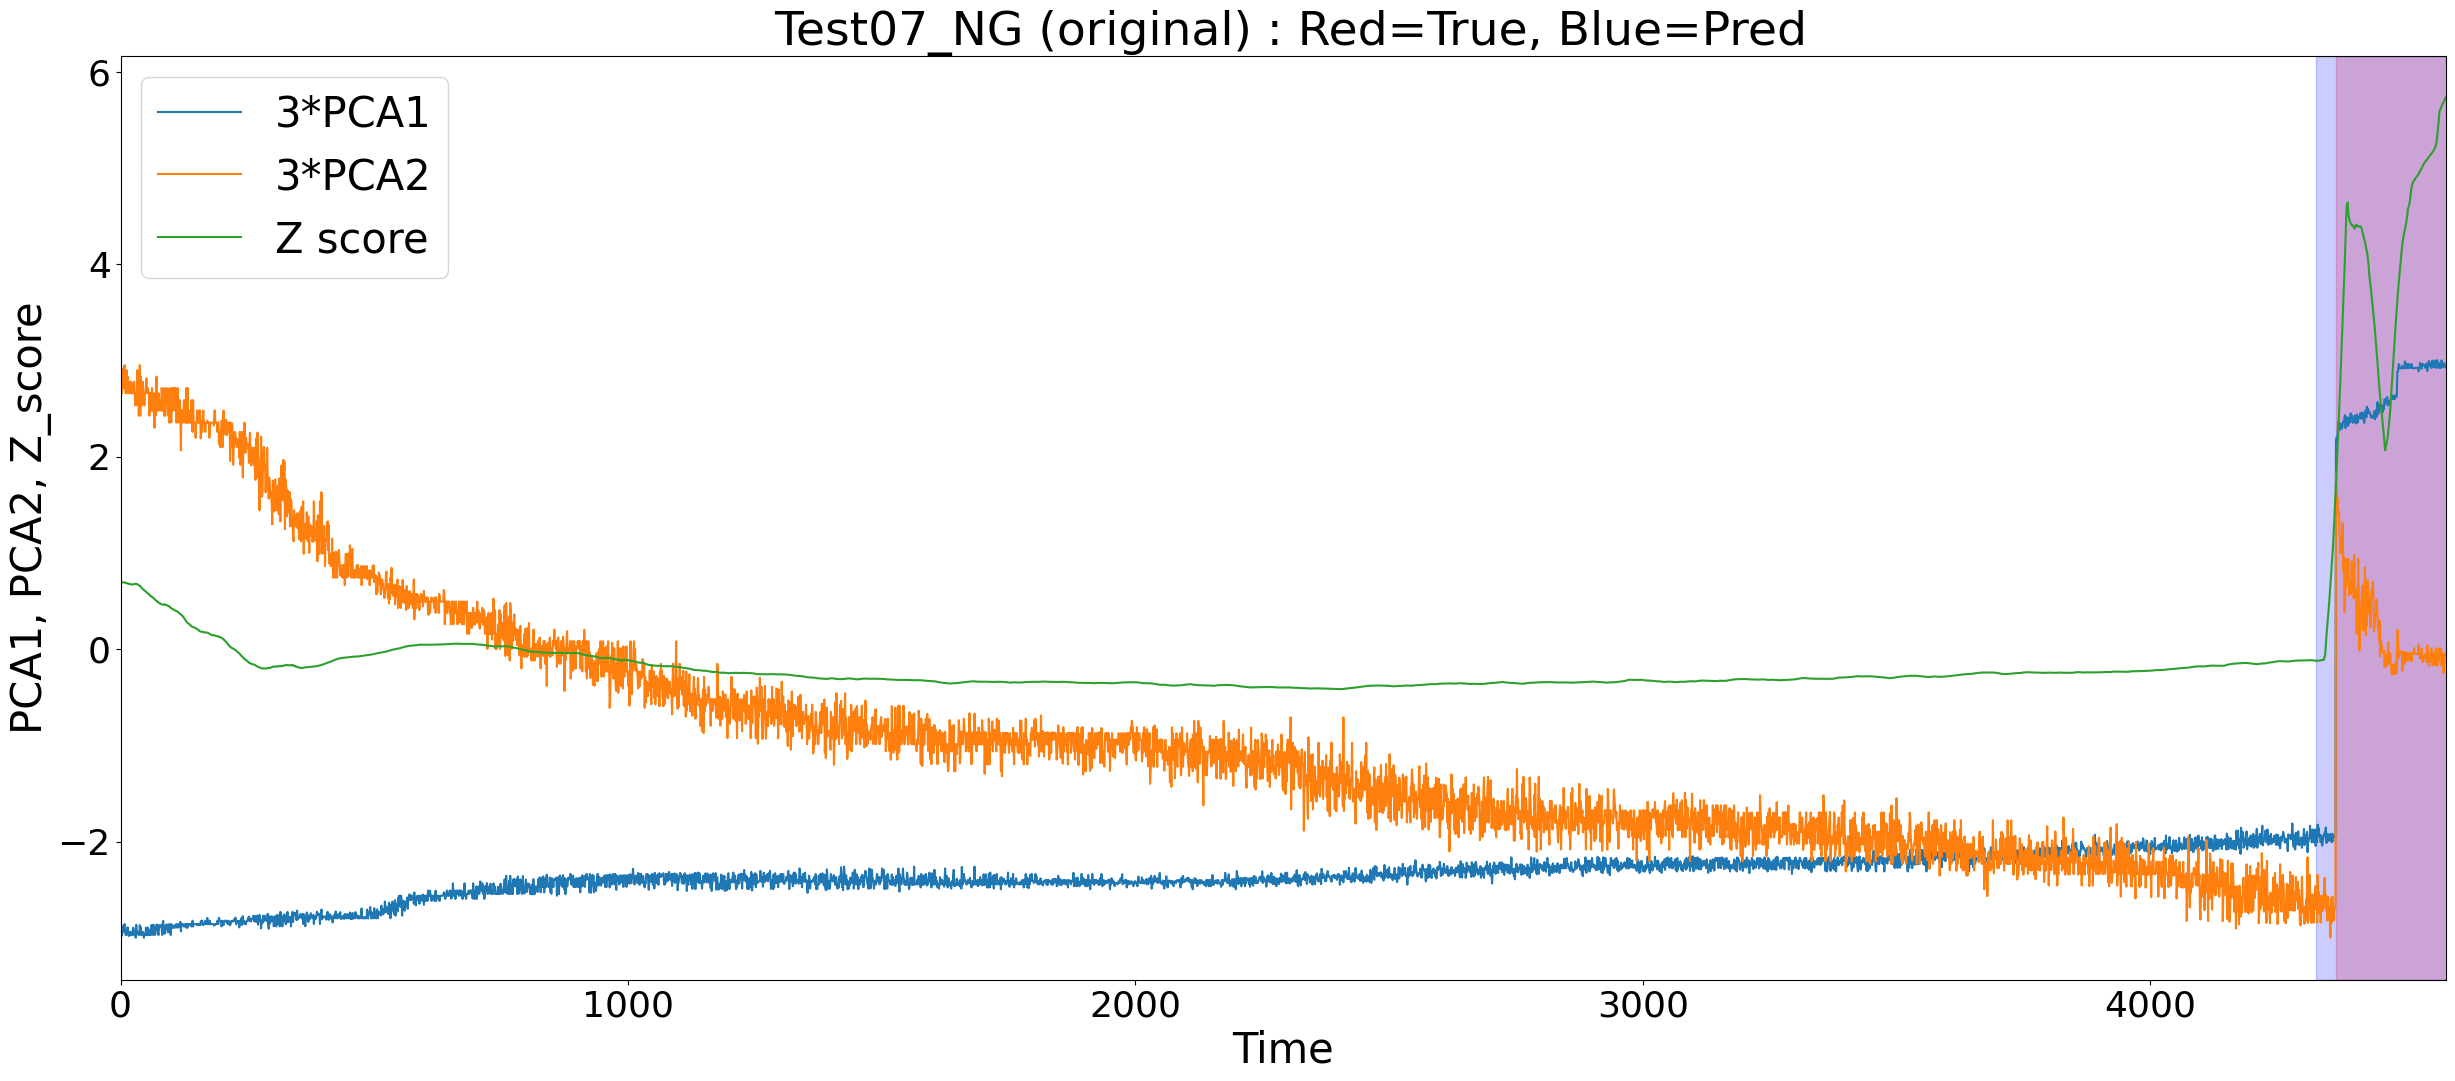

In [10]:
register_matplotlib_converters()
np.random.seed(0)
max_len = length_anom - 10
t = range(max_len)
Z2 = Z_score1[:max_len]
X_sig = np.array([X[kk, 1] for kk in range(max_len)])

plt.figure(figsize=(30, 12))
plt.plot(t, 3 * X_sig[:, 0], label='3*PCA1')
plt.plot(t, 3 * X_sig[:, 1], label='3*PCA2')
plt.plot(t, Z2, label='Z score')
plt.legend(loc=0, fontsize=30)
colors = ['red'] + ['blue'] * (len(anomalies_plot) - 1)
for i, anom_span in enumerate(anomalies_plot):
    for anom in anom_span:
        plt.axvspan(anom[0], anom[1], color=colors[i], alpha=0.2)
plt.title(' {} ({}) : Red=True, Blue=Pred'.format(TITLE, pca_mode), size=34)
plt.ylabel('PCA1, PCA2, Z_score', size=30); plt.xlabel('Time', size=30)
plt.xticks(size=26); plt.yticks(size=26)
plt.xlim([t[0], t[-1]]); plt.show()

## 추가 검증을 위한 코드베이스

In [11]:
import pandas as pd

train_cols = set(pd.read_csv('./data/preprocessed/train/1000_chg.csv').columns)
test_cols  = set(pd.read_csv('./data/preprocessed/test/Test07_NG_dchg.csv').columns)

print("학습 컬럼 수:", len(train_cols))
print("테스트 컬럼 수:", len(test_cols))
print("공통 컬럼 수:", len(train_cols & test_cols))
print("학습에만 있는 컬럼:", sorted(train_cols - test_cols)[:10])
print("테스트에만 있는 컬럼:", sorted(test_cols - train_cols)[:10])

학습 컬럼 수: 208
테스트 컬럼 수: 208
공통 컬럼 수: 208
학습에만 있는 컬럼: []
테스트에만 있는 컬럼: []


In [12]:
arguments=collections.namedtuple('Args',
 'signal_file timest_form anomaly_file mode aggregate_interval regate_interval')

args=arguments(signal_file = './data/preprocessed/train/1000_chg.csv',
 timest_form = 0,
 anomaly_file = '',
 mode = 'train',
 aggregate_interval = 1,
 regate_interval = 1)

known_anomalies = pd.read_csv(args.anomaly_file)
anom_labels=known_anomalies['label']
true0 = anom_labels
print("true0 :")
print(true0.tail(40))
pred_length =len(final_scores)
avg = np.average(final_scores)
sigma = math.sqrt(sum((final_scores-avg) * (final_scores-avg)) /len(final_scores))
Z_score1 = (final_scores-avg) / sigma
pred_bin=[0]*pred_length
for i in range(len(anomalies)):
 print( anomalies[i][0], anomalies[i][1])
 for k in range(anomalies[i][0]-1, anomalies[i][1]):
    pred_bin[k]=1
true = []
true = true0[: pred_length]
pred = np.array(pred_bin)
gt = np.array(true)
n_pred =len(pred)
tp=0
tn=0
fp=0
fn=0
for i in range(n_pred):
 if pred[i]==1 and gt[i] ==1:
    tp = tp+1
 if pred[i]==0 and gt[i] ==1:
    fn = fn+1
 if pred[i]==1 and gt[i] ==0:
    fp = fp+1
 if pred[i]==0 and gt[i] ==0:
    tn = tn+1
Accuracy = float(tp+tn)/float(n_pred)
Precision = tp / (tp + fp) if (tp + fp) > 0 else 0
Recall = tp / (tp + fn) if (tp + fn) > 0 else 0
if Precision + Recall == 0:
    F1_score = 0
else:
    F1_score = 2.0 * (Precision * Recall) / (Precision + Recall)
print("Accuracy : {:0.4f}, Precision : {:0.4f}, Recall : {:0.4f}, F-score : {:0.4f} ".format(
 Accuracy, Precision, Recall, F1_score))

FileNotFoundError: [Errno 2] No such file or directory: ''

In [ ]:
arguments = collections.namedtuple('Args', 'signal_file timest_form anomaly_file mode aggregate_interval regate_interval')

args = arguments(
    signal_file = './data/preprocessed/train/1000_chg.csv',
    timest_form = 0,
    anomaly_file = '',  # 정답지가 없으므로 비워둠
    mode = 'train',
    aggregate_interval = 1,
    regate_interval = 1
)

# 예측 결과 길이에 맞춰 pred_bin 생성 (위 코드에서 final_scores와 anomalies는 이미 있다고 가정)
pred_length = len(final_scores)
pred_bin = [0] * pred_length

print("예측된 이상치 구간:")
for i in range(len(anomalies)):
    print(anomalies[i][0], anomalies[i][1])
    for k in range(anomalies[i][0]-1, anomalies[i][1]):
        pred_bin[k] = 1

# ==========================================
# 평가(Evaluation) 파트: 파일이 있을 때만 실행
# ==========================================
if args.anomaly_file:
    known_anomalies = pd.read_csv(args.anomaly_file)
    anom_labels = known_anomalies['label']
    true0 = anom_labels
    
    print("true0 :")
    print(true0.tail(40))
    
    true = true0[: pred_length]
    pred = np.array(pred_bin)
    gt = np.array(true)
    n_pred = len(pred)
    
    tp = tn = fp = fn = 0
    for i in range(n_pred):
        if pred[i] == 1 and gt[i] == 1: tp += 1
        if pred[i] == 0 and gt[i] == 1: fn += 1
        if pred[i] == 1 and gt[i] == 0: fp += 1
        if pred[i] == 0 and gt[i] == 0: tn += 1
            
    Accuracy = float(tp+tn)/float(n_pred)
    Precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    Recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    F1_score = 2.0 * (Precision * Recall) / (Precision + Recall) if (Precision + Recall) > 0 else 0
    
    print(f"Accuracy : {Accuracy:0.4f}, Precision : {Precision:0.4f}, Recall : {Recall:0.4f}, F-score : {F1_score:0.4f}")
else:
    print("\n[알림] anomaly_file 경로가 비어있어 성능 평가(Accuracy, F1-score 계산 등)를 생략합니다.")

NameError: name 'collections' is not defined

In [ ]:
import sys
print(sys.executable)

: 